# exp9 — Variant 4: directed contact-seeding search (CB, LDDT-CB)

Companion to `contact_seeding_search_all_ranges.ipynb` (Variant 3,
greedy + sample-MAE). V3 was bottlenecked by per-candidate MAE
evaluation: each round ran inference for up to 10 candidate
contacts × 300 sample CA-CA pairs (~3000 prompts) just to pick
the next contact, on top of a final full-matrix prediction.

**V4 replaces that with a directed-search heuristic.** At each
round we already need *one* full-matrix prediction (to score
LDDT), so we let that prediction drive the candidate ranking
too: pick the remaining candidate whose **predicted expected
distance is largest**. Intuition: a candidate is by definition a
true contact (GT CB-CB ≤ 8 Å), so if the model already predicts
it as close the seed is redundant; if the model predicts it as
far apart the seed corrects an actual misconception. No per-
candidate inference at all — just a sort over `pred[i-1, j-1]`.

Other deltas vs V3:
- **Everything is CB-CB**: GT uses `cb_or_ca_position` (CB, falling
  back to CA for GLY), and the model is queried with
  `query_atom="CB"`. The training-data convention matches —
  `<CB>` tokens emitted during training were computed with the
  same CB-or-CA-for-GLY rule.
- **Only LDDT-CB is tracked** (no MAE). LDDT uses the standard
  CASP convention: 15 Å inclusion, thresholds 0.5/1/2/4 Å,
  per-residue mean over thresholds, global mean over residues.
- **No early stop on MAE.** Runs to MAX_CONTACTS=30 (or until
  candidates are exhausted) so the curve shape is fully visible.

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

EXP_DIR = Path.cwd()
REPO_ROOT = EXP_DIR.parents[1]
sys.path.insert(0, str(EXP_DIR))

import inference_helpers as IH
IH.add_exp1_to_path()

from parse import parse_structure
from select_test_proteins import select_test_proteins, download_cif

print("repo root:", REPO_ROOT)

repo root: /home/bizon/git/MarinFold


## Resolve `1B` model + same 10 test proteins

In [2]:
with (REPO_ROOT / "MODELS.yaml").open() as fh:
    models = yaml.safe_load(fh)

MODEL_NICK = "1B"
model_entry = next(m for m in models if m["nickname"] == MODEL_NICK)
assert "contacts-and-distances-v1" in model_entry["document_structures"], model_entry
MODEL_HF_URL = model_entry["url"]
_, _, tail = MODEL_HF_URL.partition("huggingface.co/")
parts = tail.split("/")
MODEL_REPO = "/".join(parts[:2])
MODEL_SUBFOLDER = parts[4] if len(parts) > 4 and parts[2] == "tree" else None
print(f"using model: {MODEL_NICK} = {MODEL_REPO}/{MODEL_SUBFOLDER}")

SEED = 0
N_PROTEINS = 10
MAX_SEQ_LEN = 150
specs = select_test_proteins(n=N_PROTEINS, seed=SEED, max_seq_len=MAX_SEQ_LEN)
CACHE_DIR = EXP_DIR / "data" / "afdb_cache"
structures = []
for spec in specs:
    cif_path = download_cif(spec, CACHE_DIR)
    parsed = parse_structure(cif_path)
    structures.append((spec, parsed))
    print(f"  {spec.entry_id}: {len(parsed.residues)} residues")

using model: 1B = timodonnell/LlamaFold-experiments/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

select_test_proteins: skipped 4 retired entries: ['AF-A0A352P7D8-F1', 'AF-A0A1K1WRR2-F1', 'AF-A0A6M1XDR8-F1', 'AF-A6D053-F1']
  AF-A0A1C5BRX1-F1: 72 residues
  AF-A0A2P2Q6H4-F1: 55 residues
  AF-E6UJZ8-F1: 112 residues
  AF-A0A1G4A0Q3-F1: 114 residues
  AF-A0A6B0Z5B5-F1: 112 residues
  AF-A0A7W4UDR7-F1: 131 residues
  AF-C6S3E2-F1: 140 residues
  AF-A0A1N7G8C0-F1: 60 residues
  AF-R7G5V6-F1: 132 residues
  AF-A0A1H0PBF4-F1: 94 residues


In [3]:
os.environ.setdefault("VLLM_LOGGING_LEVEL", "WARNING")

from huggingface_hub import snapshot_download

MODEL_LOCAL = Path(snapshot_download(
    repo_id=MODEL_REPO,
    allow_patterns=[f"{MODEL_SUBFOLDER}/*"] if MODEL_SUBFOLDER else None,
))
if MODEL_SUBFOLDER:
    MODEL_LOCAL = MODEL_LOCAL / MODEL_SUBFOLDER
print("model local path:", MODEL_LOCAL)

llm, tokenizer = IH.load_vllm(MODEL_LOCAL)
DISTANCE_TOKEN_IDS = IH.resolve_distance_token_ids(tokenizer)
print(f"resolved {len(DISTANCE_TOKEN_IDS)} distance tokens")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model local path: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/2922df683506f2549a02633d8ddcaa4d9df8900b/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


`torch_dtype` is deprecated! Use `dtype` instead!


WARNING 05-22 08:58:48 cuda.py:95] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used


WARNING 05-22 08:58:48 config.py:685] Async output processing is not supported on the current platform type cuda.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


resolved 64 distance tokens


## Candidate counts by range

Same candidate pool as V3: long + medium + short range, all with
CB-CB ≤ 8 Å cutoff.

In [4]:
candidate_pools = {}
gt_cb_matrices = {}
for spec, parsed in structures:
    all_c = IH.gt_contacts_all_ranges(parsed)
    n_long = sum(1 for c in all_c if c[0] == "<long-range-contact>")
    n_med = sum(1 for c in all_c if c[0] == "<medium-range-contact>")
    n_short = sum(1 for c in all_c if c[0] == "<short-range-contact>")
    candidate_pools[spec.entry_id] = all_c
    gt_cb_matrices[spec.entry_id] = IH.cb_distance_matrix(parsed)
    print(f"  {spec.entry_id}: long={n_long:>3}  medium={n_med:>3}  short={n_short:>3}  total={len(all_c):>4}")

  AF-A0A1C5BRX1-F1: long=  0  medium=  0  short=  4  total=   4
  AF-A0A2P2Q6H4-F1: long= 17  medium= 41  short= 22  total=  80
  AF-E6UJZ8-F1: long=113  medium= 18  short= 31  total= 162
  AF-A0A1G4A0Q3-F1: long= 45  medium= 14  short= 13  total=  72
  AF-A0A6B0Z5B5-F1: long= 59  medium= 20  short= 12  total=  91
  AF-A0A7W4UDR7-F1: long=116  medium= 71  short= 56  total= 243
  AF-C6S3E2-F1: long=156  medium= 45  short= 29  total= 230
  AF-A0A1N7G8C0-F1: long=  0  medium=  0  short=  2  total=   2
  AF-R7G5V6-F1: long= 21  medium=  3  short= 16  total=  40
  AF-A0A1H0PBF4-F1: long= 37  medium=  0  short= 10  total=  47


## Directed search per protein

Pure rank-by-predicted-distance. No per-candidate inference; the
full-matrix prediction we run for LDDT also drives the ranking.

In [5]:
MAX_CONTACTS = 30


def directed_search_cb(spec, parsed):
    """Pick contacts by descending predicted CB-CB distance.

    Selected contacts are 3-tuples ``(type_token, i, j)`` with
    1-indexed positions, matching `gt_contacts_all_ranges`.
    """
    candidates = candidate_pools[spec.entry_id]
    gt_cb = gt_cb_matrices[spec.entry_id]
    if not candidates:
        # No seeding possible — still measure the zero-shot LDDT.
        t0 = time.time()
        pred = IH.predict_distance_matrix(
            llm=llm, tokenizer=tokenizer, parsed=parsed,
            seeded_contacts=[],
            distance_token_ids=DISTANCE_TOKEN_IDS,
            query_atom="CB",
        )
        lddt = IH.lddt_from_distance_matrices(pred, gt_cb)
        elapsed = time.time() - t0
        return {
            "entry_id": spec.entry_id,
            "n_candidates": 0,
            "trace": [{
                "k": 0,
                "added_contact": None,
                "added_contact_type": None,
                "predicted_distance_before_seeding_a": None,
                "lddt_cb": lddt,
                "elapsed_seconds": elapsed,
            }],
            "selected_contacts": [],
            "search_terminated": "no candidate contacts at any range",
            "final_pred": pred,
        }

    selected: list[tuple[str, int, int]] = []
    trace = []

    t0 = time.time()
    pred = IH.predict_distance_matrix(
        llm=llm, tokenizer=tokenizer, parsed=parsed,
        seeded_contacts=[],
        distance_token_ids=DISTANCE_TOKEN_IDS,
        query_atom="CB",
    )
    lddt = IH.lddt_from_distance_matrices(pred, gt_cb)
    print(f"  k=0 LDDT(CB) = {lddt:.3f} ({time.time()-t0:.1f}s)")
    trace.append({
        "k": 0,
        "added_contact": None,
        "added_contact_type": None,
        "predicted_distance_before_seeding_a": None,
        "lddt_cb": lddt,
        "elapsed_seconds": time.time() - t0,
    })

    while len(selected) < MAX_CONTACTS:
        remaining = [c for c in candidates if c not in selected]
        if not remaining:
            return {
                "entry_id": spec.entry_id,
                "n_candidates": len(candidates),
                "trace": trace,
                "selected_contacts": selected,
                "search_terminated": "exhausted candidates",
                "final_pred": pred,
            }
        # Rank by current model-predicted CB-CB distance, descending.
        # `pred` is 0-indexed; candidate i, j are 1-indexed.
        def _score(c):
            v = pred[c[1] - 1, c[2] - 1]
            return float(v) if np.isfinite(v) else -np.inf
        remaining.sort(key=_score, reverse=True)
        best_contact = remaining[0]
        predicted_dist = _score(best_contact)
        selected.append(best_contact)

        t0 = time.time()
        pred = IH.predict_distance_matrix(
            llm=llm, tokenizer=tokenizer, parsed=parsed,
            seeded_contacts=selected,
            distance_token_ids=DISTANCE_TOKEN_IDS,
            query_atom="CB",
        )
        lddt = IH.lddt_from_distance_matrices(pred, gt_cb)
        elapsed = time.time() - t0
        type_short = best_contact[0].strip("<>").replace("-range-contact", "")
        trace.append({
            "k": len(selected),
            "added_contact": best_contact,
            "added_contact_type": type_short,
            "predicted_distance_before_seeding_a": predicted_dist,
            "lddt_cb": lddt,
            "elapsed_seconds": elapsed,
        })
        print(f"  k={len(selected)} +{type_short}({best_contact[1]},{best_contact[2]}) "
              f"pred_d={predicted_dist:.2f}Å -> LDDT(CB) = {lddt:.3f} ({elapsed:.1f}s)")

    return {
        "entry_id": spec.entry_id,
        "n_candidates": len(candidates),
        "trace": trace,
        "selected_contacts": selected,
        "search_terminated": f"reached MAX_CONTACTS={MAX_CONTACTS}",
        "final_pred": pred,
    }


results = []
for spec, parsed in structures:
    print(f"\n{spec.entry_id} ({len(parsed.residues)} residues, {len(candidate_pools[spec.entry_id])} candidates):")
    res = directed_search_cb(spec, parsed)
    print(f"  -> {res['search_terminated']}; selected {len(res['selected_contacts'])} contacts")
    results.append(res)


AF-A0A1C5BRX1-F1 (72 residues, 4 candidates):


  k=0 LDDT(CB) = 0.767 (6.9s)


  k=1 +short(50,57) pred_d=8.05Å -> LDDT(CB) = 0.760 (6.9s)


  k=2 +short(32,40) pred_d=6.83Å -> LDDT(CB) = 0.771 (7.4s)


  k=3 +short(29,37) pred_d=6.05Å -> LDDT(CB) = 0.774 (7.3s)


...

  k=26 +long(34,83) pred_d=6.36Å -> LDDT(CB) = 0.717 (24.4s)


  k=27 +long(27,71) pred_d=6.36Å -> LDDT(CB) = 0.722 (24.5s)


  k=28 +long(47,90) pred_d=6.26Å -> LDDT(CB) = 0.721 (25.1s)


  k=29 +long(35,82) pred_d=6.05Å -> LDDT(CB) = 0.728 (25.0s)


  k=30 +long(35,79) pred_d=5.85Å -> LDDT(CB) = 0.729 (25.6s)
  -> reached MAX_CONTACTS=30; selected 30 contacts


## Per-protein summary

In [6]:
import csv

PLOTS_DIR = EXP_DIR / "plots"
DATA_DIR = EXP_DIR / "data"
PLOTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(f"{'entry_id':<24} {'n_res':>5} {'cands':>6} {'k':>4} {'long':>4} {'med':>4} {'short':>5} {'LDDT@0':>8} {'LDDT@k':>8}  status")
rows = []
for (spec, parsed), res in zip(structures, results, strict=True):
    sel = res["selected_contacts"]
    k = len(sel)
    n_long = sum(1 for c in sel if c[0] == "<long-range-contact>")
    n_med = sum(1 for c in sel if c[0] == "<medium-range-contact>")
    n_short = sum(1 for c in sel if c[0] == "<short-range-contact>")
    initial_lddt = res["trace"][0]["lddt_cb"] if res["trace"] else float("nan")
    final_lddt = res["trace"][-1]["lddt_cb"] if res["trace"] else float("nan")
    rows.append({
        "entry_id": spec.entry_id,
        "uniprot_accession": spec.uniprot_accession,
        "n_residues": len(parsed.residues),
        "n_candidate_contacts": res["n_candidates"],
        "k_selected": k,
        "n_long_selected": n_long,
        "n_medium_selected": n_med,
        "n_short_selected": n_short,
        "selected_contacts": "; ".join(
            f"{c[0].strip('<>').replace('-range-contact','')}:{c[1]}-{c[2]}" for c in sel),
        "initial_lddt_cb": initial_lddt,
        "final_lddt_cb": final_lddt,
        "search_terminated": res["search_terminated"],
    })
    print(f"{spec.entry_id:<24} {len(parsed.residues):>5} {res['n_candidates']:>6} "
          f"{k:>4} {n_long:>4} {n_med:>4} {n_short:>5} "
          f"{initial_lddt:>8.3f} {final_lddt:>8.3f}  {res['search_terminated']}")

with (DATA_DIR / "contact_directed_search_summary.csv").open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0]))
    w.writeheader()
    w.writerows(rows)
print(f"\nwrote {(DATA_DIR / 'contact_directed_search_summary.csv').relative_to(REPO_ROOT)}")

# Per-(protein, k) trace CSV.
trace_rows = []
for (spec, _), res in zip(structures, results, strict=True):
    for step in res["trace"]:
        added = step["added_contact"]
        trace_rows.append({
            "entry_id": spec.entry_id,
            "k": step["k"],
            "added_contact_type": step["added_contact_type"],
            "added_contact_i": added[1] if added else "",
            "added_contact_j": added[2] if added else "",
            "predicted_distance_before_seeding_a": step["predicted_distance_before_seeding_a"]
                if step["predicted_distance_before_seeding_a"] is not None else "",
            "lddt_cb": step["lddt_cb"],
            "elapsed_seconds": step["elapsed_seconds"],
        })
if trace_rows:
    with (DATA_DIR / "contact_directed_search_trace.csv").open("w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(trace_rows[0]))
        w.writeheader()
        w.writerows(trace_rows)
    print(f"wrote {(DATA_DIR / 'contact_directed_search_trace.csv').relative_to(REPO_ROOT)}")

entry_id                 n_res  cands    k long  med short   LDDT@0   LDDT@k  status
AF-A0A1C5BRX1-F1            72      4    4    0    0     4    0.767    0.784  exhausted candidates
AF-A0A2P2Q6H4-F1            55     80   30    8   12    10    0.357    0.804  reached MAX_CONTACTS=30
AF-E6UJZ8-F1               112    162   30   23    1     6    0.346    0.693  reached MAX_CONTACTS=30
AF-A0A1G4A0Q3-F1           114     72   30   16    8     6    0.397    0.702  reached MAX_CONTACTS=30
AF-A0A6B0Z5B5-F1           112     91   30   17    6     7    0.552    0.786  reached MAX_CONTACTS=30
AF-A0A7W4UDR7-F1           131    243   30   22    4     4    0.316    0.627  reached MAX_CONTACTS=30
AF-C6S3E2-F1               140    230   30   21    4     5    0.244    0.525  reached MAX_CONTACTS=30
AF-A0A1N7G8C0-F1            60      2    2    0    0     2    0.755    0.753  exhausted candidates
AF-R7G5V6-F1               132     40   30   15    3    12    0.616    0.767  reached MAX_CONTACTS=30
AF-

## LDDT-CB trace plot

One line per protein, full-matrix LDDT(CB) at each round. The
directed-search picks tend to start with long-range contacts (the
model is most-wrong about those) and shift toward medium/short as
the structure gets refined — the colored markers in the CSV's
`added_contact_type` column show that mix.

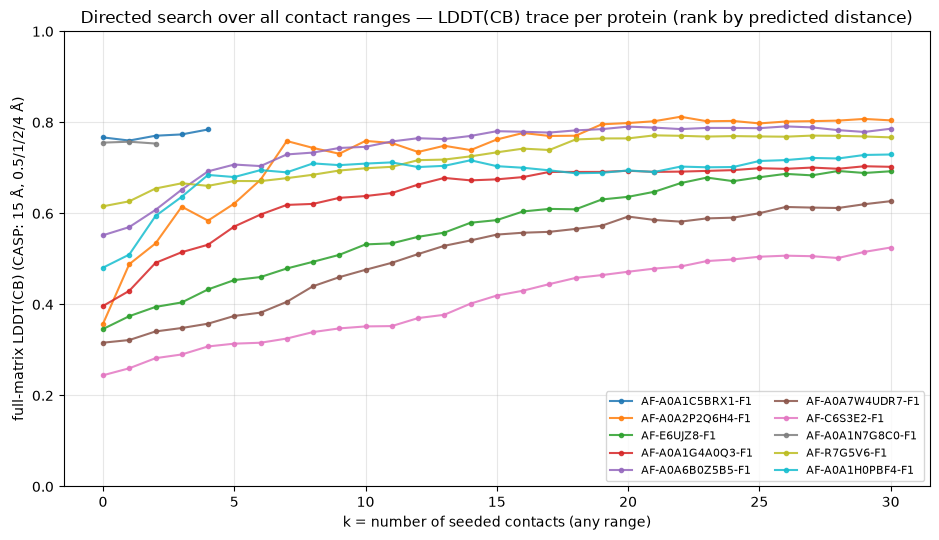

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for (spec, _), res in zip(structures, results, strict=True):
    if not res["trace"]:
        continue
    ks = [step["k"] for step in res["trace"]]
    lddts = [step["lddt_cb"] for step in res["trace"]]
    ax.plot(ks, lddts, "-o", markersize=3, label=spec.entry_id, alpha=0.85)
ax.set_xlabel("k = number of seeded contacts (any range)")
ax.set_ylabel("full-matrix LDDT(CB) (CASP: 15 Å, 0.5/1/2/4 Å)")
ax.set_ylim(0.0, 1.0)
ax.set_title(f"Directed search over all contact ranges — LDDT(CB) trace per protein "
             f"(rank by predicted distance)")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "contact_directed_search_trace.png", dpi=110)
plt.show()

## Final heatmaps with selected contacts (10 × 3 grid)

CB-CB distances (CA-for-GLY). GT, predicted-with-seeded, and
absolute residual per protein.

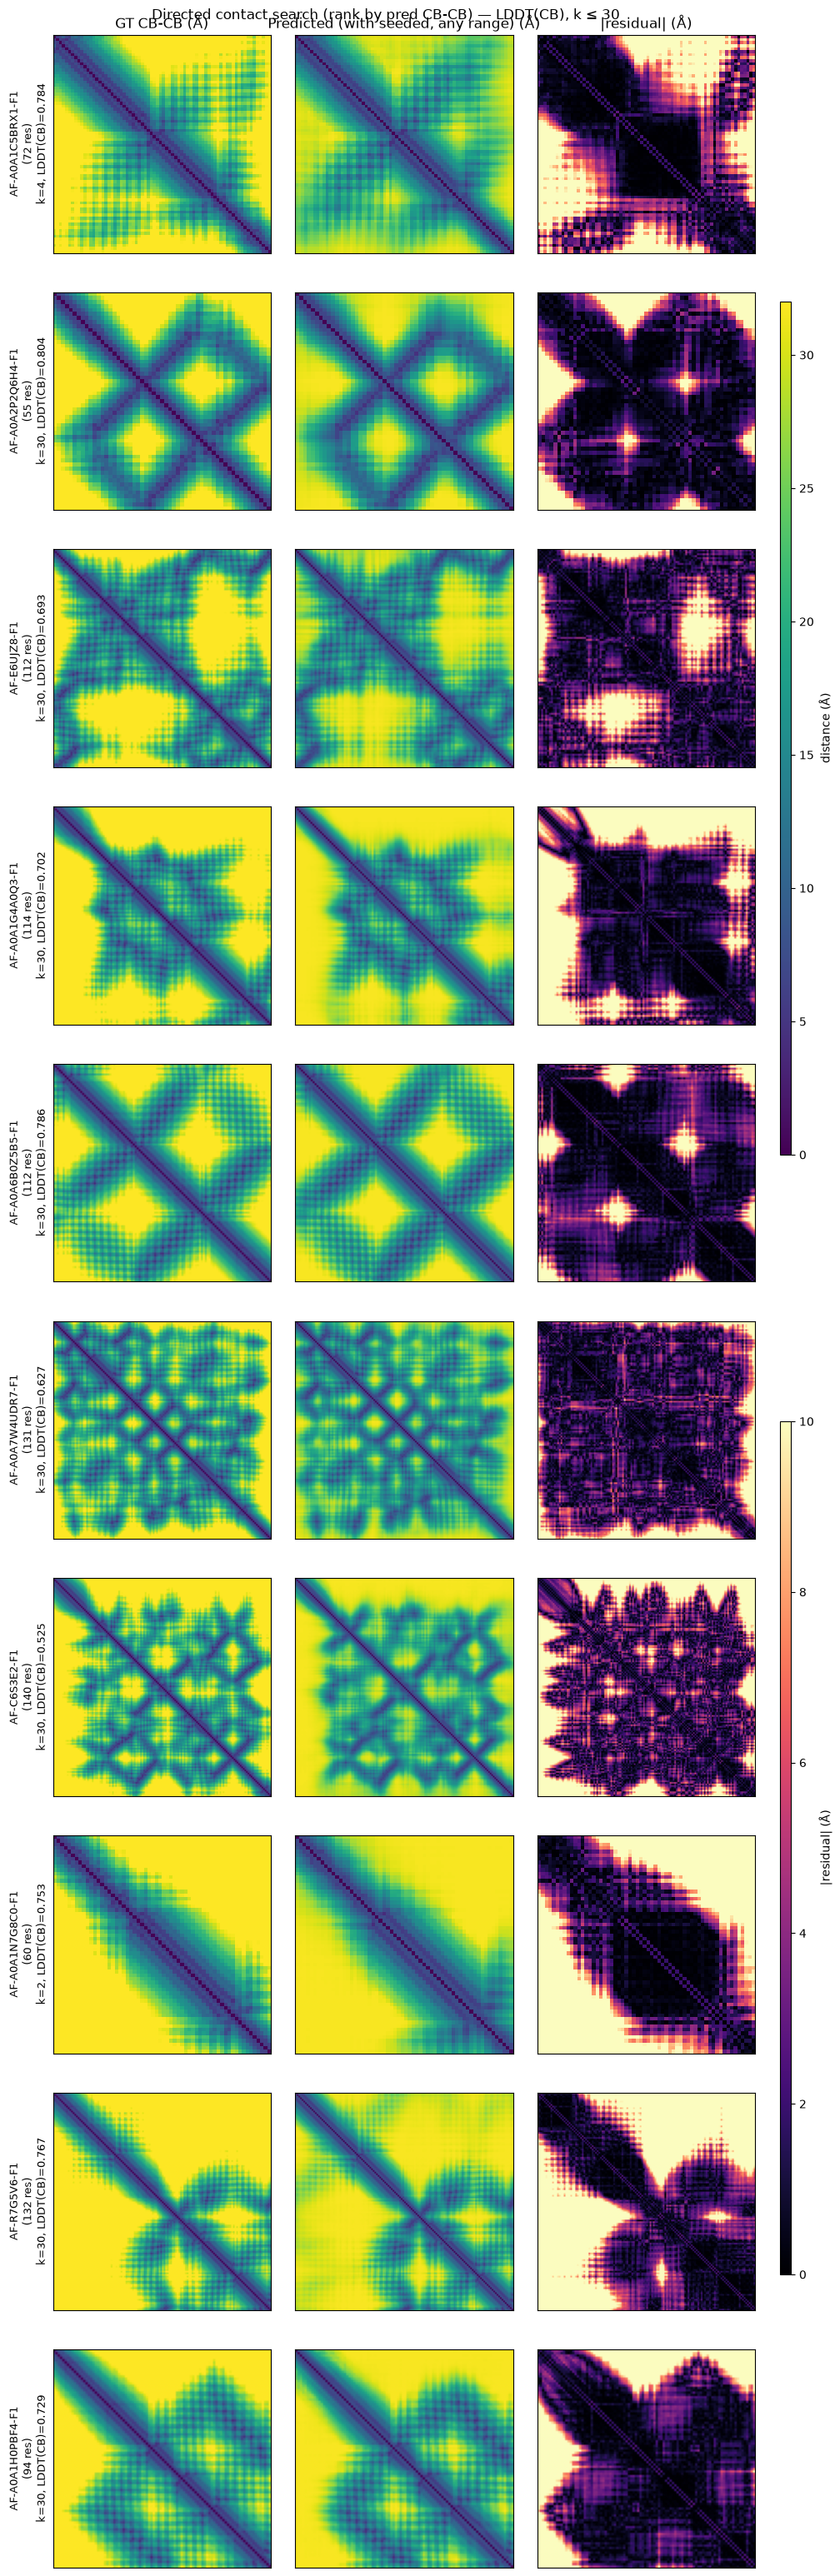

saved experiments/exp9_evals_test_distance_heatmaps/plots/contact_directed_search_grid.png


In [8]:
n_proteins = len(structures)
fig, axes = plt.subplots(n_proteins, 3, figsize=(11, 3.2 * n_proteins), squeeze=False)
for row, ((spec, parsed), res) in enumerate(zip(structures, results, strict=True)):
    gt = gt_cb_matrices[spec.entry_id]
    pred = res["final_pred"]
    abs_err = np.abs(pred - gt)
    n = gt.shape[0]
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    valid = (ii != jj) & np.isfinite(gt) & (gt <= IH.DISTANCE_MAX_A)
    k = len(res["selected_contacts"])
    final_lddt = res["trace"][-1]["lddt_cb"] if res["trace"] else float("nan")

    im0 = axes[row, 0].imshow(gt, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im1 = axes[row, 1].imshow(pred, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im2 = axes[row, 2].imshow(abs_err, vmin=0, vmax=10.0, cmap="magma")

    axes[row, 0].set_ylabel(f"{spec.entry_id}\n({n} res)\nk={k}, LDDT(CB)={final_lddt:.3f}", fontsize=9)
    if row == 0:
        axes[row, 0].set_title("GT CB-CB (Å)")
        axes[row, 1].set_title("Predicted (with seeded, any range) (Å)")
        axes[row, 2].set_title("|residual| (Å)")
    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

cbar_dist = fig.add_axes([0.93, 0.55, 0.012, 0.32])
fig.colorbar(im1, cax=cbar_dist, label="distance (Å)")
cbar_err = fig.add_axes([0.93, 0.13, 0.012, 0.32])
fig.colorbar(im2, cax=cbar_err, label="|residual| (Å)")
fig.suptitle(
    f"Directed contact search (rank by pred CB-CB) — LDDT(CB), k ≤ {MAX_CONTACTS}",
    fontsize=12,
)
fig.subplots_adjust(left=0.13, right=0.91, top=0.97, bottom=0.02, hspace=0.18, wspace=0.05)
fig.savefig(PLOTS_DIR / "contact_directed_search_grid.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"saved {(PLOTS_DIR / 'contact_directed_search_grid.png').relative_to(REPO_ROOT)}")

## Summary

Compare against V3 (`contact_seeding_search_all_ranges.ipynb`):
- V3 search strategy: per round, randomly sample ≤10 remaining
  candidates, run inference on each (300 sample CA-CA pairs),
  pick the lowest-MAE; then a separate post-hoc LDDT-CA replay.
- V4 search strategy (this notebook): no per-candidate inference.
  The full-matrix CB-CB prediction we run for LDDT at each round
  also drives the candidate ranking — pick the candidate the
  model is currently most wrong about (largest predicted CB-CB
  distance). One full-matrix prediction per round, period.

Expected: V4 should run in ~⅔ of V3's wall time, with broadly
similar LDDT-vs-k curves (the heuristic is a sensible proxy for
information gain, even if not provably optimal).